In [1]:
import os
import cdflib # for cdf load 
import cdflib.cdfwrite
import numpy as np
import pandas as pd
from datetime import datetime, timedelta, time, date
import matplotlib.pyplot as plt
import glob
from typing import Dict, Union
from apexpy import Apex
from chaosmagpy import load_CHAOS_matfile
from chaosmagpy.coordinate_utils import transform_points
from chaosmagpy.coordinate_utils import geo_to_gg
from chaosmagpy.data_utils import mjd2000, load_RC_datfile
from my_utils import load_cdf_file, load_folder_to_dataframe, mjd2000_to_datetime, datetime_to_mjd2000, gd2gc, gc2gd, my_chaos, downsample_to_1min, nez_to_gg, compute_declination
from baseline import BaselineEstimator, CoordinateRotator, VarianceEstimator, InverseCoordinateRotator
from IPython.display import clear_output


In [2]:
model = load_CHAOS_matfile('CHAOS-8.5.mat')

In [4]:
times = np.load('concurrent_times_supermag.npy',allow_pickle=True)

# If your array is in datetime64[D] or finer resolution, cast to month precision first
year_months = times.astype('datetime64[M]')

unique_year_months = np.unique(year_months)
unique_year_months = pd.DatetimeIndex(unique_year_months)
print(unique_year_months)

stations = np.load('stations_supermag.npy', allow_pickle=True)
print(stations)

df_loc = pd.read_csv('SuperMAG_stations.csv')

DatetimeIndex(['2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-04-01',
               '2025-05-01', '2025-06-01'],
              dtype='datetime64[s]', freq=None)
['BJN' 'DMH' 'GDH' 'HOP' 'HOV' 'HRN' 'IQA' 'JAN' 'KUV' 'LRV' 'LYR' 'NAL'
 'NAN' 'NAQ' 'PGC' 'RES' 'SKT' 'STF' 'SUM' 'THL']


In [ ]:

for y_m in unique_year_months:
    year = y_m.year
    month = y_m.month
    folder_data = f'supermag_downloads/no_baseline/{year}/'
    folder_out = f'supermag_downloads/yearly_BASELINE_v2/{year}/'
    for sta in ['KUV']:
        file_data = f'supermag_{sta}_{year}_{month}.csv'
        file_path_data = folder_data + file_data
        file_path_out = folder_out + file_data

        if os.path.exists(file_path_out):
            print(f'File for {sta} in month {month} already exists')
            continue
    
        GLON = df_loc[df_loc['IAGA']==sta]['GLON'].values
        GLAT = df_loc[df_loc['IAGA']==sta]['GLAT'].values

        apex_obj = Apex(date=datetime(year, month, 12), refh=0)
        mlat = apex_obj.convert(GLAT, GLON, "geo", "apex", height=0)[0]
        mlat = mlat[0]

        df_data = pd.read_csv(file_path_data)
        df_data['time'] = pd.to_datetime(df_data['time'])
        df_data= df_data.sort_values(by='time')

        ###
        rotator = CoordinateRotator(df_data['time'].to_numpy(), df_data['dbn_geo'].to_numpy(), df_data['dbe_geo'].to_numpy(), df_data['dbz_geo'].to_numpy())
        rotator.rotate()
        bn, be, bu = rotator.get_components()

        ve = VarianceEstimator(df_data['time'].to_numpy(), bn, be, bu, mlat)
        ve.estimate()

        # Estimate baselines for all three rotated components before mapping the
        # result back into the original XYZ frame.
        be_e = BaselineEstimator(df_data['time'].to_numpy(), be, ve.df["uE"].values, mlat, component="E")
        be_e.get_baseline()

        be_n = BaselineEstimator(df_data['time'].to_numpy(), bn, ve.df["uN"].values, mlat, component="N")
        be_n.get_baseline()

        be_u = BaselineEstimator(df_data['time'].to_numpy(), bu, ve.df["uZ"].values, mlat, component="Z")
        be_u.get_baseline()

        QY_n = be_n.df["QY"].values
        QY_e = be_e.df["QY"].values
        QY_u = be_u.df["QY"].values

        dbn_nez = bn - QY_n
        dbe_nez = be - QY_e
        dbz_nez = bu - QY_u

        time_mjd2000 = 8900.0
        dbn_geo, dbe_geo, dbz_geo = nez_to_gg(dbn_nez, dbe_nez, dbz_nez, lat_gg=74.57, lon=302.82, alt_km=0.0, time_mjd2000=time_mjd2000, model=model)

        df_out = df_data.copy()
        df_out = df_out.drop(columns=['dbn_nez','dbe_nez','dbz_nez'])
        df_out['dbn_geo'] = dbn_geo
        df_out['dbe_geo'] = dbe_geo
        df_out['dbz_geo'] = dbz_geo

        file_path_out = folder_out + file_data
        df_out.to_csv(file_path_out, index=False)

        clear_output()
        print(f'{sta} {year} {month} done!')


KUV 2023 2 done!


In [8]:
test = pd.read_csv('supermag_downloads/yearly_BASELINE/2023/supermag_KUV_2023_2.csv')
test['time'] = pd.to_datetime(test['time'])
test['t_mjd'] = datetime_to_mjd2000(test['time'].values)
test

,time,ext,iaga,dbn_geo,dbe_geo,dbz_geo,t_mjd
0,2023-02-01 00:00:00,60.0,KUV,20.324954,-9.235738,-0.912289,8432.000000
1,2023-02-01 00:01:00,60.0,KUV,20.080986,-8.610794,-0.451351,8432.000694
2,2023-02-01 00:02:00,60.0,KUV,19.087269,-8.300178,-0.373226,8432.001389
3,2023-02-01 00:03:00,60.0,KUV,17.420709,-8.435999,-0.244319,8432.002083
4,2023-02-01 00:04:00,60.0,KUV,15.670980,-8.191123,-0.201350,8432.002778
...,...,...,...,...,...,...,...
40315,2023-02-28 23:55:00,60.0,KUV,NaN,NaN,NaN,8459.996528
40316,2023-02-28 23:56:00,60.0,KUV,NaN,NaN,NaN,8459.997222
40317,2023-02-28 23:57:00,60.0,KUV,NaN,NaN,NaN,8459.997917
40318,2023-02-28 23:58:00,60.0,KUV,NaN,NaN,NaN,8459.998611


In [51]:
times = np.load('concurrent_times_dtu.npy',allow_pickle=True)

# If your array is in datetime64[D] or finer resolution, cast to month precision first
year_months = times.astype('datetime64[M]')

unique_year_months = np.unique(year_months)
unique_year_months = pd.DatetimeIndex(unique_year_months)
print(unique_year_months)

stations = np.load('stations_dtu.npy', allow_pickle=True)
print(stations)

df_loc = pd.read_csv('dtu_stations.csv')

folders = ['GDH6', 'KUL2', 'KUV1', 'NAQ4m', 'NRD2', 'PIF4', 'SCO2', 'SKT1', 'STF2', 'SUM1', 'SVS1']

DatetimeIndex(['2023-02-01', '2023-03-01', '2023-04-01', '2023-05-01',
               '2023-06-01', '2023-07-01', '2023-08-01', '2023-09-01',
               '2023-10-01', '2023-11-01', '2023-12-01', '2024-01-01',
               '2024-02-01', '2024-04-01', '2024-05-01', '2024-06-01',
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-04-01', '2025-05-01'],
              dtype='datetime64[s]', freq=None)
['GDH' 'KUL' 'KUV' 'NAQ' 'NRD' 'PIF' 'SCO' 'SKT' 'STF' 'SUM' 'SVS']


**KALLES METHOD WITH NEZ BASELINE**

In [ ]:
from scipy.interpolate import CubicSpline

def interpolate_declination_fast(rotator, t_target):
    """
    Interpolate the smoothed declination onto arbitrary target timestamps
    using scipy CubicSpline instead of the slow per-sample Python loop.

    Parameters
    ----------
    rotator : CoordinateRotator
        A rotator that has already run up to smooth_declination().
    t_target : array-like of datetime64 or Timestamps
        The timestamps to interpolate onto (e.g. your 1-second grid).

    Returns
    -------
    q : np.ndarray
        Declination values at each target timestamp.
    """
    t_nodes = rotator.q_daily.index.values.astype("datetime64[s]").astype(float)
    y_nodes = rotator.q_smooth

    # Only interpolate over the valid node range; extrapolate as constant
    cs = CubicSpline(t_nodes, y_nodes, extrapolate=False)

    t_full = pd.to_datetime(t_target).values.astype("datetime64[s]").astype(float)
    q = cs(t_full)

    # Fill any out-of-range extrapolation with edge values
    q = np.where(t_full < t_nodes[0],  y_nodes[0],  q)
    q = np.where(t_full > t_nodes[-1], y_nodes[-1], q)

    return q

In [ ]:
for y_m in unique_year_months:
    year = y_m.year
    month = y_m.month
    month_str = str(month).zfill(2)
    for folder in ['GDH6']:

        folder_data = f'dtu_downloads/{folder}/{year}/'
        folder_out = f'dtu_downloads/yearly_BASELINE_v2/{folder}/'
        if not os.path.exists(folder_out):
            os.makedirs(folder_out)
        
        sta = folder[0:3]
        file_out = f'dtu_{sta}_{year}_{month}_test.parquet'
        file_path_out = folder_out + file_out

        if os.path.exists(file_path_out):
            print(f'File for {sta} in month {month} already exists')
            continue

        GLON = df_loc[df_loc['IAGA']==sta]['lon_gd'].values
        GLAT = df_loc[df_loc['IAGA']==sta]['lat_gd'].values

        apex_obj = Apex(date=datetime(year, month, 12), refh=0)
        mlat = apex_obj.convert(GLAT, GLON, "geo", "apex", height=0)[0]
        mlat = mlat[0]

        cdf_files = glob.glob(os.path.join(folder_data, f'*{year}{month_str}*.cdf'))
        df_data = []
        for filepath in cdf_files:
            filename = os.path.basename(filepath)
            try:
                X, Y, Z, t_mjd = load_cdf_file(filepath)
                time = mjd2000_to_datetime(t_mjd)
                df = pd.DataFrame({'X':X,'Y':Y,'Z':Z,'t_mjd':t_mjd,'time':time})

                df_data.append(df)

            except Exception as e:
                print(f"Warning: Failed to load {filename}: {e}")

        df_data = pd.concat(df_data, ignore_index=True)
        df_data = df_data.sort_values(by='time', ignore_index=True)
        df_data.set_index('time', inplace=True)

        cols_to_smooth = ['X','Y','Z']
        df_data_ds = downsample_to_1min(df_data[cols_to_smooth], input_rate="1s", nan_threshold=0.5)

        # --- Step 1: Estimate declination on 1-minute data (fast) ---
        rotator_1min = CoordinateRotator(df_data_ds.index.to_numpy(), df_data_ds['X'].to_numpy(), df_data_ds['Y'].to_numpy(), df_data_ds['Z'].to_numpy())
        rotator_1min.df["datetime"] = pd.to_datetime(rotator_1min.df["datetime"])

        rotator_1min.rotate()
        bn, be, bu = rotator_1min.get_components()

        # Estimate declination on 1-minute data as before
        rotator_1min.get_declination_raw()
        rotator_1min.get_declination_daily()
        rotator_1min.smooth_declination()
        # Skip interpolate_declination() entirely

        # Interpolate fast onto 1-second timestamps
        q_1sec = interpolate_declination_fast(rotator_1min, df_data.index.values)

        # Apply rotation directly
        x = np.asarray(df_data['X'].to_numpy(), dtype=float)
        y = np.asarray(df_data['Y'].to_numpy(), dtype=float)
        z = np.asarray(df_data['Z'].to_numpy(), dtype=float)
        bn_sec = x * np.cos(q_1sec) + y * np.sin(q_1sec)
        be_sec = -x * np.sin(q_1sec) + y * np.cos(q_1sec)
        bu_sec = z


        ve = VarianceEstimator(df_data_ds.index.to_numpy(), bn, be, bu, mlat)
        ve.estimate()

        # Estimate baselines for all three rotated components before mapping the
        # result back into the original XYZ frame.
        be_e = BaselineEstimator(df_data_ds.index.to_numpy(), be, ve.df["uE"].values, mlat, component="E")
        be_e.get_baseline()

        be_n = BaselineEstimator(df_data_ds.index.to_numpy(), bn, ve.df["uN"].values, mlat, component="N")
        be_n.get_baseline()

        be_u = BaselineEstimator(df_data_ds.index.to_numpy(), bu, ve.df["uZ"].values, mlat, component="Z")
        be_u.get_baseline()

        QY_n_min = be_n.df["QY"].values
        QY_e_min = be_e.df["QY"].values
        QY_u_min = be_u.df["QY"].values
        
        t_nodes = be_n.df["datetime"].values.astype('datetime64[s]').astype(float)
        t_full = df_data.index.values.astype('datetime64[s]').astype(float)

        QY_n = np.interp(t_full, t_nodes, QY_n_min)
        QY_e = np.interp(t_full, t_nodes, QY_e_min)
        QY_u = np.interp(t_full, t_nodes, QY_u_min)

        dbn_nez = bn_sec - QY_n
        dbe_nez = be_sec - QY_e
        dbz_nez = bu_sec - QY_u

        df_out = df_data.copy()
        df_out = df_out.reset_index()
        df_out['time'] = pd.to_datetime(df_out['time'])
        df_out['time'] = df_out['time'].astype('datetime64[ns]')
        #df_out['X'] = dbn_geo
        #df_out['Y'] = dbe_geo
        #df_out['Z'] = dbz_geo
        df_out['X'] = dbn_nez
        df_out['Y'] = dbe_nez
        df_out['Z'] = dbz_nez


        file_out = f'dtu_{sta}_{year}_{month}_test.parquet'
        file_path_out = folder_out + file_out
        df_out.to_parquet(file_path_out, engine='fastparquet')

        clear_output()
        print(f'{sta} {year} {month} done!')



GDH 2025 4 done!



**TEST USING 1 DAY DTU DATA ONLY**

In [77]:
times = np.load('concurrent_times_dtu.npy',allow_pickle=True)

# If your array is in datetime64[D] or finer resolution, cast to month precision first
year_month_days = times.astype('datetime64[D]')

unique_year_month_days = np.unique(year_month_days)
unique_year_month_days = pd.DatetimeIndex(unique_year_month_days)
print(unique_year_month_days)

stations = np.load('stations_dtu.npy', allow_pickle=True)
print(stations)

df_loc = pd.read_csv('dtu_stations.csv')

folders = ['GDH6', 'KUL2', 'KUV1', 'NAQ4m', 'NRD2', 'PIF4', 'SCO2', 'SKT1', 'STF2', 'SUM1', 'SVS1']

DatetimeIndex(['2023-02-23', '2023-02-24', '2023-02-25', '2023-03-23',
               '2023-03-24', '2023-03-25', '2023-03-26', '2023-03-27',
               '2023-03-28', '2023-03-29',
               ...
               '2025-04-27', '2025-04-28', '2025-04-29', '2025-04-30',
               '2025-05-01', '2025-05-02', '2025-05-03', '2025-05-04',
               '2025-05-05', '2025-05-06'],
              dtype='datetime64[s]', length=409, freq=None)
['GDH' 'KUL' 'KUV' 'NAQ' 'NRD' 'PIF' 'SCO' 'SKT' 'STF' 'SUM' 'SVS']


In [100]:
test_day = datetime(2025,4,12)

In [107]:
for y_m_d in [test_day]:
    year = y_m_d.year
    month = y_m_d.month
    day = y_m_d.day
    month_str = str(month).zfill(2)
    day_str = str(day).zfill(2)
    for folder in ['GDH6']:

        folder_data = f'dtu_downloads/{folder}/{year}/'
        folder_out = f'dtu_downloads/yearly_BASELINE_v2/{folder}/'
        if not os.path.exists(folder_out):
            os.makedirs(folder_out)
        
        sta = folder[0:3]
        file_out = f'dtu_{sta}_{year}_{month}_daytest.parquet'
        file_path_out = folder_out + file_out

        if os.path.exists(file_path_out):
            print(f'File for {sta} in month {month} already exists')
            continue

        GLON = df_loc[df_loc['IAGA']==sta]['lon_gd'].values
        GLAT = df_loc[df_loc['IAGA']==sta]['lat_gd'].values

        apex_obj = Apex(date=datetime(year, month, 12), refh=0)
        mlat = apex_obj.convert(GLAT, GLON, "geo", "apex", height=0)[0]
        mlat = mlat[0]

        cdf_files = glob.glob(os.path.join(folder_data, f'*{year}{month_str}{day_str}*.cdf'))
        df_data = []
        for filepath in cdf_files:
            filename = os.path.basename(filepath)
            try:
                X, Y, Z, t_mjd = load_cdf_file(filepath)
                time = mjd2000_to_datetime(t_mjd)
                df = pd.DataFrame({'X':X,'Y':Y,'Z':Z,'t_mjd':t_mjd,'time':time})

                df_data.append(df)

            except Exception as e:
                print(f"Warning: Failed to load {filename}: {e}")

        df_data = pd.concat(df_data, ignore_index=True)
        df_data = df_data.sort_values(by='time', ignore_index=True)
        df_data.set_index('time', inplace=True)

        cols_to_smooth = ['X','Y','Z']
        df_data_ds = downsample_to_1min(df_data[cols_to_smooth], input_rate="1s", nan_threshold=0.5)

        rotator_min = CoordinateRotator(df_data_ds.index.to_numpy(), df_data_ds['X'].to_numpy(), df_data_ds['Y'].to_numpy(), df_data_ds['Z'].to_numpy())
        rotator_min.rotate()
        bn, be, bu = rotator_min.get_components()
        
        rotator_sec = CoordinateRotator(df_data.index.to_numpy(), df_data['X'].to_numpy(), df_data['Y'].to_numpy(), df_data['Z'].to_numpy())
        rotator_sec.rotate()
        bn_sec, be_sec, bu_sec = rotator_sec.get_components()

        ve = VarianceEstimator(df_data_ds.index.to_numpy(), bn, be, bu, mlat)
        ve.estimate()

        # Estimate baselines for all three rotated components before mapping the
        # result back into the original XYZ frame.
        be_e = BaselineEstimator(df_data_ds.index.to_numpy(), be, ve.df["uE"].values, mlat, component="E")
        be_e.get_baseline()

        be_n = BaselineEstimator(df_data_ds.index.to_numpy(), bn, ve.df["uN"].values, mlat, component="N")
        be_n.get_baseline()

        be_u = BaselineEstimator(df_data_ds.index.to_numpy(), bu, ve.df["uZ"].values, mlat, component="Z")
        be_u.get_baseline()

        QY_n_min = be_n.df["QY"].values
        QY_e_min = be_e.df["QY"].values
        QY_u_min = be_u.df["QY"].values
        
        t_nodes = be_n.df["datetime"].values.astype('datetime64[s]').astype(float)
        t_full = df_data.index.values.astype('datetime64[s]').astype(float)

        QY_n = np.interp(t_full, t_nodes, QY_n_min)
        QY_e = np.interp(t_full, t_nodes, QY_e_min)
        QY_u = np.interp(t_full, t_nodes, QY_u_min)

        dbn_nez = bn_sec - QY_n
        dbe_nez = be_sec - QY_e
        dbz_nez = bu_sec - QY_u

        df_out = df_data.copy()
        df_out = df_out.reset_index()
        df_out['time'] = pd.to_datetime(df_out['time'])
        df_out['time'] = df_out['time'].astype('datetime64[ns]')

        D = compute_declination(GLAT, GLON, 0, 9000, model)
        theta = -D[0] * np.pi/180
        rot = np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])
        YXrot = rot@np.vstack([dbe_nez, dbn_nez])
        Y_rot = YXrot[0,:]
        X_rot = YXrot[1,:]

        df_out['X'] = X_rot
        df_out['Y'] = Y_rot
        df_out['Z'] = dbz_nez


        file_out = f'dtu_{sta}_{year}_{month}_daytest.parquet'
        file_path_out = folder_out + file_out
        df_out.to_parquet(file_path_out, engine='fastparquet')

        clear_output()
        print(f'{sta} {year} {month} done!')



GDH 2025 4 done!


**DAYTEST OVER**

In [3]:
sup0 = pd.read_csv('supermag_downloads/yearly_baseline/2025/supermag_GDH_2025_4.csv')
sup0['time'] = pd.to_datetime(sup0['time'])
sup0['t_mjd'] = datetime_to_mjd2000(sup0['time'].values)

sup1 = pd.read_csv('supermag_downloads/yearly_BASELINE/2025/supermag_GDH_2025_4.csv')
sup1['time'] = pd.to_datetime(sup1['time'])
sup1['t_mjd'] = datetime_to_mjd2000(sup1['time'].values)

#sup2 = pd.read_csv('supermag_downloads/yearly_BASELINE_v2/2023/supermag_KUV_2023_2.csv')
#sup2['time'] = pd.to_datetime(sup2['time'])
#sup2['t_mjd'] = datetime_to_mjd2000(sup2['time'].values)

dtu1 = pd.read_parquet('dtu_downloads/yearly_BASELINE/GDH6/dtu_GDH_2025_4.parquet', engine='fastparquet')
dtu2 = pd.read_parquet('dtu_downloads/yearly_BASELINE_v2/GDH6/dtu_GDH_2025_4.parquet', engine='fastparquet')
dtu_rot = pd.read_parquet('dtu_downloads/yearly_BASELINE_rotated/GDH6/dtu_GDH_2025_4.parquet', engine='fastparquet')
dtu_day = pd.read_parquet('dtu_downloads/yearly_BASELINE_v2/GDH6/dtu_GDH_2025_4_daytest.parquet', engine='fastparquet')
 

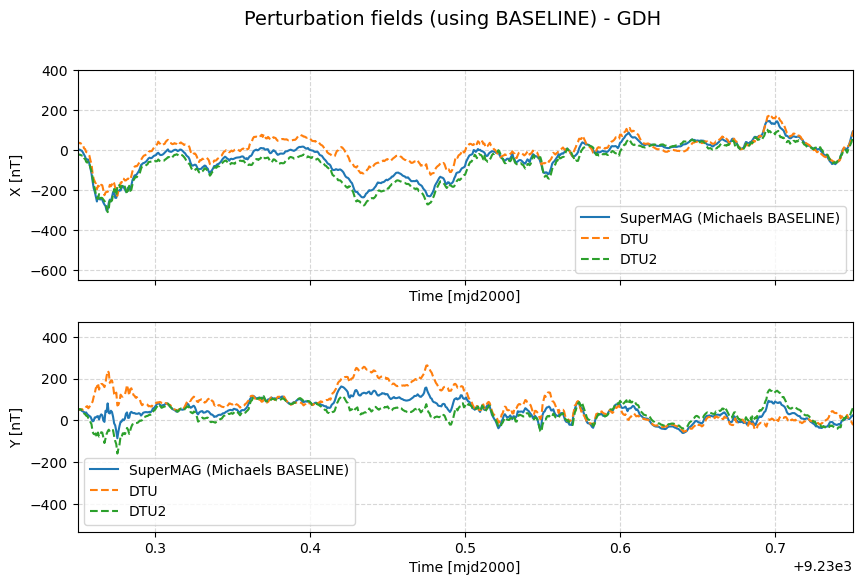

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
fig.suptitle("Perturbation fields (using BASELINE) - GDH", fontsize=14, y=0.98)

axes[0].plot(sup1['t_mjd'],sup1['dbn_geo'], ls='-', label = 'SuperMAG (Michaels BASELINE)')
axes[0].plot(dtu1['t_mjd'].values[::60],dtu1['X'].values[::60], ls='--', label = 'DTU')
axes[0].plot(dtu2['t_mjd'].values[::60],dtu2['X'].values[::60], ls='--', label = 'DTU2')
#axes[0].plot(sup0['t_mjd'],sup0['dbn_geo'], ls='--', label = 'SuperMAG (SuperMAG baseline)')
axes[0].set_ylabel('X [nT]')
axes[0].set_xlabel('Time [mjd2000]')
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

axes[1].plot(sup1['t_mjd'],sup1['dbe_geo'], ls='-', label = 'SuperMAG (Michaels BASELINE)')
axes[1].plot(dtu1['t_mjd'].values[::60],dtu1['Y'].values[::60], ls='--', label = 'DTU')
axes[1].plot(dtu2['t_mjd'].values[::60],dtu2['Y'].values[::60], ls='--', label = 'DTU2')
#axes[1].plot(sup0['t_mjd'],sup0['dbe_geo'], ls='--', label = 'SuperMAG (SuperMAG baseline)')
axes[1].set_ylabel('Y [nT]')
axes[1].set_xlabel('Time [mjd2000]')
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].set_xlim((9230.25,9230.75))

plt.show()

In [18]:
D = compute_declination(69.25, 306.47, 0, 9300, model)

theta = -D[0] * np.pi/180

rot = np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])

YXrot = rot@np.vstack([dtu2['Y'].values,dtu2['X'].values])
Y_dtu_rot_sup = YXrot[0,:]
X_dtu_rot_sup = YXrot[1,:]

In [5]:
theta = -35.7 * np.pi/180

rot = np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])

YXrot = rot@np.vstack([dtu1['Y'].values,dtu1['X'].values])
Y_dtu_rot_man = YXrot[0,:]
X_dtu_rot_man = YXrot[1,:]

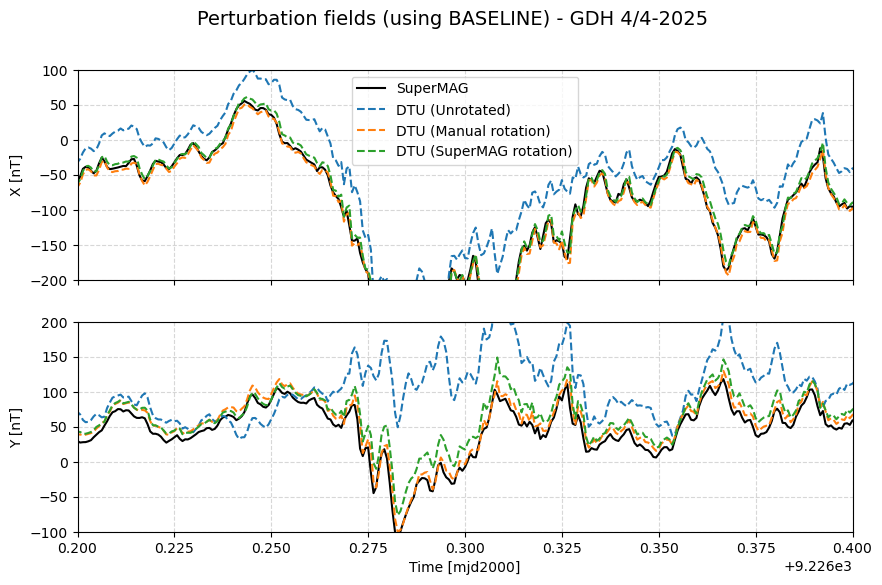

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
fig.suptitle("Perturbation fields (using BASELINE) - GDH 4/4-2025", fontsize=14, y=0.98)

axes[0].plot(sup1['t_mjd'],sup1['dbn_geo'], ls='-', color = 'black',label = 'SuperMAG')
#axes[0].plot(sup0['t_mjd'],sup0['dbn_geo'], ls='-.', label = 'SuperMAG')
axes[0].plot(dtu1['t_mjd'].values[::60],dtu1['X'].values[::60], ls='--', label = 'DTU (Unrotated)')
#axes[0].plot(dtu2['t_mjd'].values[::60],dtu2['X'].values[::60], ls='--', label = 'DTU NEZ')
axes[0].plot(dtu1['t_mjd'].values[::60],X_dtu_rot_man[::60], ls='--', label = 'DTU (Manual rotation)')
axes[0].plot(dtu2['t_mjd'].values[::60],X_dtu_rot_sup[::60], ls='--', label = 'DTU (SuperMAG rotation)')
#axes[0].plot(dtu1['t_mjd'].values[::60],X_dtu_rot1[::60], ls='--', label = 'DTU (Manuel rotation)')
#axes[0].plot(dtu_day['t_mjd'].values[::60],dtu_day['X'].values[::60], ls='--', label = 'DTU DAY')
#axes[0].plot(sup0['t_mjd'],sup0['dbn_geo'], ls='--', label = 'SuperMAG (SuperMAG baseline)')
axes[0].set_ylabel('X [nT]')
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

axes[1].plot(sup1['t_mjd'],sup1['dbe_geo'], ls='-',color='black', label = 'SuperMAG')
#axes[1].plot(sup0['t_mjd'],sup0['dbe_geo'], ls='-.', label = 'SuperMAG')
axes[1].plot(dtu1['t_mjd'].values[::60],dtu1['Y'].values[::60], ls='--', label = 'DTU (Unrotated)')
#axes[1].plot(dtu2['t_mjd'].values[::60],dtu2['Y'].values[::60], ls='--', label = 'DTU NEZ')
axes[1].plot(dtu1['t_mjd'].values[::60],Y_dtu_rot_man[::60], ls='--', label = 'DTU (Manual rotation)')
axes[1].plot(dtu2['t_mjd'].values[::60],Y_dtu_rot_sup[::60], ls='--', label = 'DTU (SuperMAG rotation)')
#axes[1].plot(dtu1['t_mjd'].values[::60],Y_dtu_rot1[::60], ls='--', label = 'DTU (Manuel rotation)')
#axes[1].plot(dtu_day['t_mjd'].values[::60],dtu_day['Y'].values[::60], ls='--', label = 'DTU DAY')
#axes[1].plot(sup0['t_mjd'],sup0['dbe_geo'], ls='--', label = 'SuperMAG (SuperMAG baseline)')
axes[1].set_ylabel('Y [nT]')
axes[1].set_xlabel('Time [mjd2000]')
#axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].set_xlim((9223.2+3,9223.4+3))
axes[0].set_ylim((-200,100))
axes[1].set_ylim((-100,200))
#axes[0].set_ylim((-610,100))


plt.show()

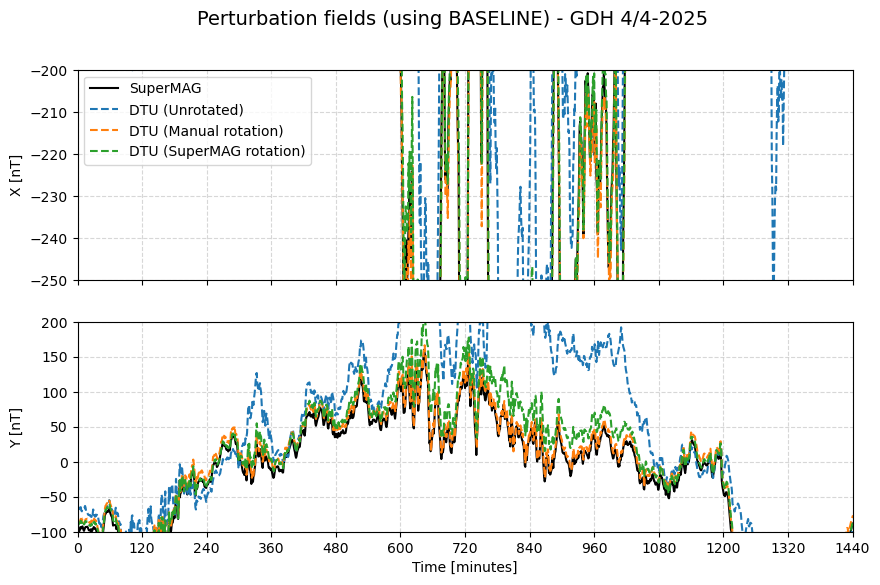

In [8]:
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
fig.suptitle("Perturbation fields (using BASELINE) - GDH 4/4-2025", fontsize=14, y=0.98)

axes[0].plot(sup1['t_mjd'],sup1['dbn_geo'], color='black', ls='-', label = 'SuperMAG')
#axes[0].plot(sup0['t_mjd'],sup0['dbn_geo'], ls='-.', label = 'SuperMAG')
axes[0].plot(dtu1['t_mjd'].values[::60],dtu1['X'].values[::60], ls='--', label = 'DTU (Unrotated)')
#axes[0].plot(dtu2['t_mjd'].values[::60],dtu2['X'].values[::60], ls='--', label = 'DTU NEZ')
axes[0].plot(dtu1['t_mjd'].values[::60],X_dtu_rot_man[::60], ls='--', label = 'DTU (Manual rotation)')
axes[0].plot(dtu2['t_mjd'].values[::60],X_dtu_rot_sup[::60], ls='--', label = 'DTU (SuperMAG rotation)')
#axes[0].plot(dtu1['t_mjd'].values[::60],X_dtu_rot1[::60], ls='--', label = 'DTU (Manuel rotation)')
#axes[0].plot(dtu_day['t_mjd'].values[::60],dtu_day['X'].values[::60], ls='--', label = 'DTU DAY')
#axes[0].plot(sup0['t_mjd'],sup0['dbn_geo'], ls='--', label = 'SuperMAG (SuperMAG baseline)')
axes[0].set_ylabel('X [nT]')
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

axes[1].plot(sup1['t_mjd'],sup1['dbe_geo'], color='black', ls='-', label = 'SuperMAG')
#axes[1].plot(sup0['t_mjd'],sup0['dbe_geo'], ls='-.', label = 'SuperMAG')
axes[1].plot(dtu1['t_mjd'].values[::60],dtu1['Y'].values[::60], ls='--', label = 'DTU (Unrotated)')
#axes[1].plot(dtu2['t_mjd'].values[::60],dtu2['Y'].values[::60], ls='--', label = 'DTU NEZ')
axes[1].plot(dtu1['t_mjd'].values[::60],Y_dtu_rot_man[::60], ls='--', label = 'DTU (Manual rotation)')
axes[1].plot(dtu2['t_mjd'].values[::60],Y_dtu_rot_sup[::60], ls='--', label = 'DTU (SuperMAG rotation)')
#axes[1].plot(dtu1['t_mjd'].values[::60],Y_dtu_rot1[::60], ls='--', label = 'DTU (Manuel rotation)')
#axes[1].plot(dtu_day['t_mjd'].values[::60],dtu_day['Y'].values[::60], ls='--', label = 'DTU DAY')
#axes[1].plot(sup0['t_mjd'],sup0['dbe_geo'], ls='--', label = 'SuperMAG (SuperMAG baseline)')
axes[1].set_ylabel('Y [nT]')
#axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)
#axes[0].set_ylim((-500,100))
axes[0].set_ylim((-250,-200))
#axes[1].set_ylim((-300,400))
axes[1].set_ylim((-100,200))
#axes[0].set_ylim((-610,100))


# Define the start of the day in mjd2000 (adjust if your day starts at a different offset)
day_start_mjd = 9222 + 3  # same left edge as your xlim

axes[1].set_xlim((day_start_mjd, day_start_mjd + 1))

# Format x-axis ticks as minutes from 0 to 1440
formatter = mticker.FuncFormatter(lambda x, _: f"{int(round((x - day_start_mjd) * 1440))}")
axes[1].xaxis.set_major_formatter(formatter)

# Set ticks every 120 minutes (adjust interval as needed)
tick_interval_mjd = 120 / 1440
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(tick_interval_mjd))

# Update x-axis labels
axes[0].set_xlabel('')          # remove label from top plot since sharex
axes[1].set_xlabel('Time [minutes]')

#plt.tight_layout()
plt.show()